# Laser threshold data: linear fits and chi-squared

Three power-vs-current datasets from the lab. Each diode/laser has a **threshold
current**: below threshold the detector just sees noise/spontaneous emission
(flat, not linear), and only *above* threshold does the power rise linearly
with current. So for each dataset we:

1. Plot power vs. current with error bars.
2. Pick (by eye) a threshold current and fit a straight line **only to the
   points above threshold**.
3. Compute the reduced chi-squared of that fit.
4. Say whether it's reasonably linear.

**On the optical table hole spacing:** standard optical tables/breadboards
(Melles Griot included) use a regular tapped-hole grid, either
**1 inch (25.4 mm) spacing** (imperial, 1/4"-20 holes) or **25 mm** (metric,
M6 holes) - 1 inch is the far more common convention for US-made tables like
Melles Griot's. Taking the 1-inch grid as the reference:

- Dataset 1: mirror-to-mirror spacing = 1 hole = **2.54 cm**; sensor-to-output-mirror
  = 2 holes = **5.08 cm**.
- Dataset 2: output-to-sensor = 41 holes = **104.1 cm** (~1.04 m).
- Dataset 3: 4 holes = **10.16 cm**.

(If your table happens to be one of the metric-grid Melles Griot models, just
multiply the hole counts by 2.5 cm instead of 2.54 cm - the numbers barely
change.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def linear(x, m, b):
    return m * x + b

def chi2_reduced(y, yfit, sigma, n_params=2):
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    dof = len(y) - n_params
    return chi2 / dof

def interpret(chi2r):
    if chi2r < 0.5:
        return "chi^2_red << 1 -> fit is very good (errors may even be a bit overestimated)."
    elif chi2r <= 2:
        return "chi^2_red ~ 1 -> reasonably linear given the stated uncertainties."
    else:
        return ("chi^2_red >> 1 -> the trend above threshold is linear in *shape*, "
                "but point-to-point scatter is larger than the reported error bars "
                "(errors likely underestimated / extra unmodeled noise), so the fit "
                "is not statistically great even though it looks linear.")


## Dataset 1

Cavity mirror spacing = 1 hole (2.54 cm), sensor-to-output-mirror = 2 holes (5.08 cm).
Lab lights: both laser room lights on, Zeeman light off.


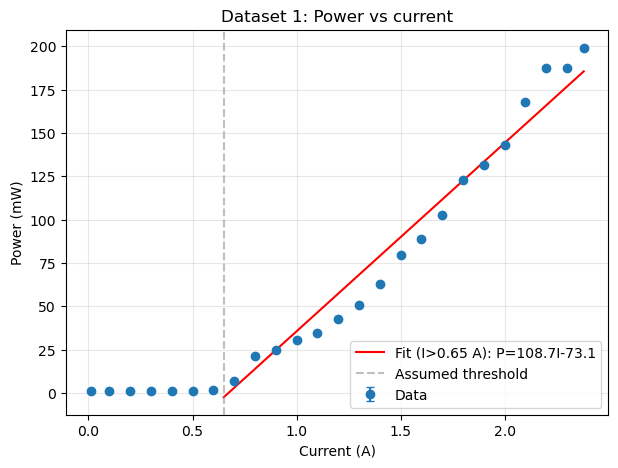

slope = 108.66 mW/A, intercept = -73.07 mW, n points fit = 18
chi^2_reduced = 3214.6
chi^2_red >> 1 -> the trend above threshold is linear in *shape*, but point-to-point scatter is larger than the reported error bars (errors likely underestimated / extra unmodeled noise), so the fit is not statistically great even though it looks linear.


In [2]:
# Current (A), Power (mW), std (microW as reported -> converted to mW)
I1 = np.array([0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,
               1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.38])
P1 = np.array([1.1,1.0,1.0,1.0,1.0,1.0,1.9,7.0,21.25,25.07,30.8,34.4,42.5,50.9,
               62.6,79.6,89.0,102.7,122.9,131.8,143.0,168.0,187.7,187.7,199.0])
std1_uW = np.array([np.nan, np.nan, 1.0, 1.84, 2.18, 4.23, 5.0, 59.43, 498.0, 183.5,
                     600.0, 280.0, 230.0, 230.0, 120.0, 640.0, 817.0, 188.0, 119.0,
                     700.0, 300.0, 124.0, 800.0, 340.0, 470.0])

sigma1 = std1_uW / 1000.0  # microW -> mW
# first two points had no reported std; use the smallest measured std as a stand-in
sigma1[np.isnan(sigma1)] = np.nanmin(sigma1)

plt.figure(figsize=(7,5))
plt.errorbar(I1, P1, yerr=sigma1, fmt='o', capsize=3, label='Data')

# below threshold it's just noise -> not linear, exclude from the fit
I1_th = 0.65
mask1 = I1 >= I1_th
popt1, _ = curve_fit(linear, I1[mask1], P1[mask1], sigma=sigma1[mask1], absolute_sigma=True)

xfit = np.linspace(I1_th, I1.max(), 100)
plt.plot(xfit, linear(xfit, *popt1), 'r-',
         label=f'Fit (I>{I1_th} A): P={popt1[0]:.1f}I{popt1[1]:+.1f}')
plt.axvline(I1_th, color='gray', ls='--', alpha=0.5, label='Assumed threshold')
plt.xlabel('Current (A)'); plt.ylabel('Power (mW)')
plt.title('Dataset 1: Power vs current')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

chi2r1 = chi2_reduced(P1[mask1], linear(I1[mask1], *popt1), sigma1[mask1])
print(f"slope = {popt1[0]:.2f} mW/A, intercept = {popt1[1]:.2f} mW, n points fit = {mask1.sum()}")
print(f"chi^2_reduced = {chi2r1:.1f}")
print(interpret(chi2r1))


## Dataset 2

Output-to-sensor distance = 41 holes (~104.1 cm).


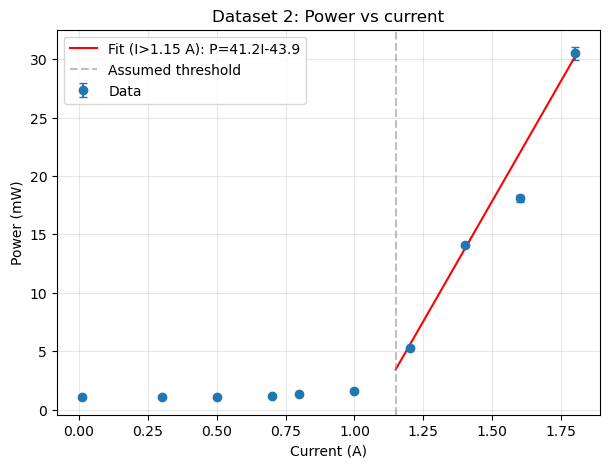

slope = 41.18 mW/A, intercept = -43.91 mW, n points fit = 4
chi^2_reduced = 103.6
chi^2_red >> 1 -> the trend above threshold is linear in *shape*, but point-to-point scatter is larger than the reported error bars (errors likely underestimated / extra unmodeled noise), so the fit is not statistically great even though it looks linear.
(Note: only 4 points go into this fit, so the chi^2_red estimate is noisy.)


In [3]:
I2 = np.array([0.01,0.30,0.50,0.70,0.80,1.00,1.20,1.40,1.60,1.80])
P2 = np.array([1.10,1.08,1.07,1.20,1.35,1.59,5.30,14.10,18.08,30.50])
std2_uW = np.array([18.0,6.0,17.0,7.0,30.0,47.0,70.0,66.0,300.0,530.0])
sigma2 = std2_uW / 1000.0

plt.figure(figsize=(7,5))
plt.errorbar(I2, P2, yerr=sigma2, fmt='o', capsize=3, label='Data')

I2_th = 1.15
mask2 = I2 >= I2_th
popt2, _ = curve_fit(linear, I2[mask2], P2[mask2], sigma=sigma2[mask2], absolute_sigma=True)

xfit = np.linspace(I2_th, I2.max(), 100)
plt.plot(xfit, linear(xfit, *popt2), 'r-',
         label=f'Fit (I>{I2_th} A): P={popt2[0]:.1f}I{popt2[1]:+.1f}')
plt.axvline(I2_th, color='gray', ls='--', alpha=0.5, label='Assumed threshold')
plt.xlabel('Current (A)'); plt.ylabel('Power (mW)')
plt.title('Dataset 2: Power vs current')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

chi2r2 = chi2_reduced(P2[mask2], linear(I2[mask2], *popt2), sigma2[mask2])
print(f"slope = {popt2[0]:.2f} mW/A, intercept = {popt2[1]:.2f} mW, n points fit = {mask2.sum()}")
print(f"chi^2_reduced = {chi2r2:.1f}")
print(interpret(chi2r2))
print("(Note: only 4 points go into this fit, so the chi^2_red estimate is noisy.)")


## Dataset 3

Pump mechanism (not the laser output itself), 4 holes (10.16 cm). The two
current sweeps given are merged and sorted by current.


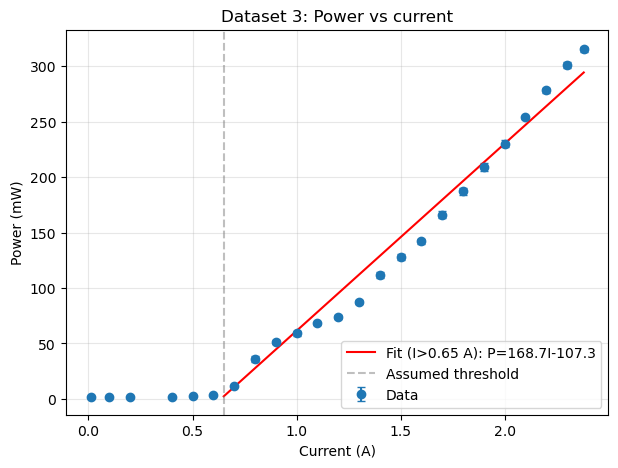

slope = 168.72 mW/A, intercept = -107.32 mW, n points fit = 18
chi^2_reduced = 60.1
chi^2_red >> 1 -> the trend above threshold is linear in *shape*, but point-to-point scatter is larger than the reported error bars (errors likely underestimated / extra unmodeled noise), so the fit is not statistically great even though it looks linear.


In [4]:
I3 = np.array([0.5,0.7,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.38,
               0.01,0.10,0.20,0.40,0.60,0.90,1.10,1.30,1.50,1.70,1.90,2.10,2.30])
P3 = np.array([2.44,11.5,36.2,59,74,112,142,187,230,278,315,
               1.56,1.80,1.80,2.11,3.47,51.50,68.00,87.70,128.00,166.20,209.00,254.00,300.70])
std3_uW = np.array([32,190,2500,2500,1500,2600,2000,3000,3000,2000,2000,
                     11,40,18,10,14,2000,1200,1700,3000,3200,3500,1400,2800], dtype=float)

order = np.argsort(I3)
I3, P3, std3_uW = I3[order], P3[order], std3_uW[order]
sigma3 = std3_uW / 1000.0

plt.figure(figsize=(7,5))
plt.errorbar(I3, P3, yerr=sigma3, fmt='o', capsize=3, label='Data')

I3_th = 0.65
mask3 = I3 >= I3_th
popt3, _ = curve_fit(linear, I3[mask3], P3[mask3], sigma=sigma3[mask3], absolute_sigma=True)

xfit = np.linspace(I3_th, I3.max(), 100)
plt.plot(xfit, linear(xfit, *popt3), 'r-',
         label=f'Fit (I>{I3_th} A): P={popt3[0]:.1f}I{popt3[1]:+.1f}')
plt.axvline(I3_th, color='gray', ls='--', alpha=0.5, label='Assumed threshold')
plt.xlabel('Current (A)'); plt.ylabel('Power (mW)')
plt.title('Dataset 3: Power vs current')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

chi2r3 = chi2_reduced(P3[mask3], linear(I3[mask3], *popt3), sigma3[mask3])
print(f"slope = {popt3[0]:.2f} mW/A, intercept = {popt3[1]:.2f} mW, n points fit = {mask3.sum()}")
print(f"chi^2_reduced = {chi2r3:.1f}")
print(interpret(chi2r3))


## Summary

All three datasets show the classic laser-diode behaviour: flat/noisy output
below a threshold current, then a roughly linear rise above it. The reduced
chi-squared values above threshold come out **much larger than 1** for all
three sets - that doesn't mean the linear model is wrong (the trend really
does look straight once lasing starts), it means the point-to-point scatter
is bigger than the small reported std's would suggest. In practice this
usually means the per-point "std" (from very few repeated readings, or a
fast fluctuating diode current) is underestimating the true run-to-run
variability, mode-hopping, or drift during the measurement. If you want
chi^2_red near 1, the most physically honest fix is to enlarge the error
bars (e.g. add a fixed relative uncertainty like 5-10% of the power in
quadrature) rather than to force a "better" fit.


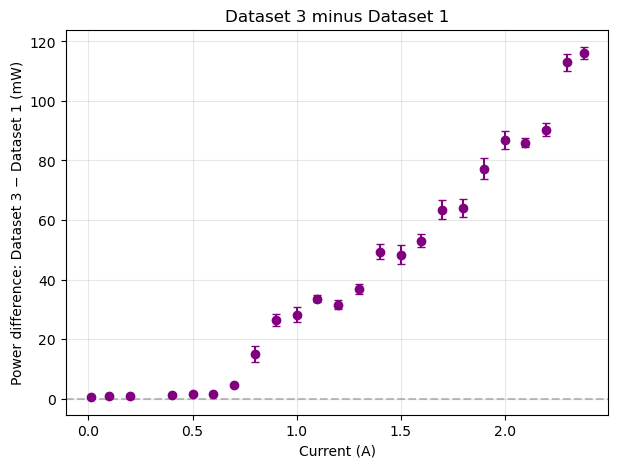

In [5]:
# Subtract Dataset 1 from Dataset 3 (interpolating Dataset 1 onto Dataset 3's
# current values, since the two didn't use the same current steps)
I1_interp     = np.interp(I3, I1, P1)
sigma1_interp = np.interp(I3, I1, sigma1)  # rough error propagation through the interpolation

P_diff     = P3 - I1_interp
sigma_diff = np.sqrt(sigma3**2 + sigma1_interp**2)

plt.figure(figsize=(7,5))
plt.errorbar(I3, P_diff, yerr=sigma_diff, fmt='o', capsize=3, color='purple')
plt.axhline(0, color='gray', ls='--', alpha=0.5)
plt.xlabel('Current (A)'); plt.ylabel('Power difference: Dataset 3 − Dataset 1 (mW)')
plt.title('Dataset 3 minus Dataset 1')
plt.grid(alpha=0.3)
plt.show()